# Repaso rápido EDA y visualización — paso a paso

Cuaderno de repaso para el examen, centrado en:

- carga y auditoría inicial,
- análisis univariante numérico y categórico,
- ANOVA y Tukey,
- correlación y scatter plots,
- series temporales.

La idea es que te sirva como **chuleta ordenada**: qué hacer, en qué orden y con qué código típico.

## 0. Librerías básicas

Estas son las librerías que más vas a usar.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para ANOVA y Tukey
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## 1. Carga y auditoría inicial

### Qué suele pedir el profesor
1. Cargar el CSV.
2. Ver estructura con `info()`.
3. Ver estadísticos con `describe()`.
4. Ver nulos.
5. Separar variables numéricas y categóricas.
6. Mostrar primeras filas.

### Código típico

In [8]:
df = pd.read_csv("ecommerce_sales.csv")

df.info()
display(df.describe())
display(df.isnull().sum())

numericas = df.select_dtypes(include=["int64", "float64"]).columns
categoricas = df.select_dtypes(include=["object", "category", "bool"]).columns

print("Variables numéricas:", list(numericas))
print("Variables categóricas:", list(categoricas))

display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

Variables numéricas: ['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age']
Variables categóricas: ['order_id', 'customer_id', 'product_id', 'category', 'payment_method', 'order_date', 'region', 'returned', 'customer_gender']


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


### Idea clave
Antes de usar una columna en un bloque, comprueba siempre:

```python
df.columns.tolist()
```

Esto evita errores como:
- `KeyError: 'date'`
- `KeyError: 'items'`

## 2. Análisis univariante de variables numéricas

Variables típicas:
- `total_amount`
- `profit_margin`
- `customer_age`

### Qué te pueden pedir
- media,
- desviación típica,
- Q1, mediana, Q3,
- IQR,
- histogramas con KDE,
- media y mediana pintadas,
- zona Q1-Q3 sombreada,
- limpieza de outliers.

In [9]:
variables = ['total_amount', 'profit_margin', 'customer_age']

for var in variables:
    media = df[var].mean()
    std = df[var].std()
    q1 = df[var].quantile(0.25)
    q2 = df[var].quantile(0.50)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1

    print(f"\nVariable: {var}")
    print(f"Media: {media:.2f}")
    print(f"Std: {std:.2f}")
    print(f"Q1: {q1:.2f}")
    print(f"Mediana: {q2:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")


Variable: total_amount
Media: 170.01
Std: 357.50
Q1: 19.71
Mediana: 56.82
Q3: 168.53
IQR: 148.82

Variable: profit_margin
Media: 28.12
Std: 53.35
Q1: 1.50
Mediana: 10.55
Q3: 33.13
IQR: 31.63

Variable: customer_age
Media: 43.47
Std: 14.98
Q1: 31.00
Mediana: 43.00
Q3: 56.00
IQR: 25.00


### Histogramas juntos en una sola figura

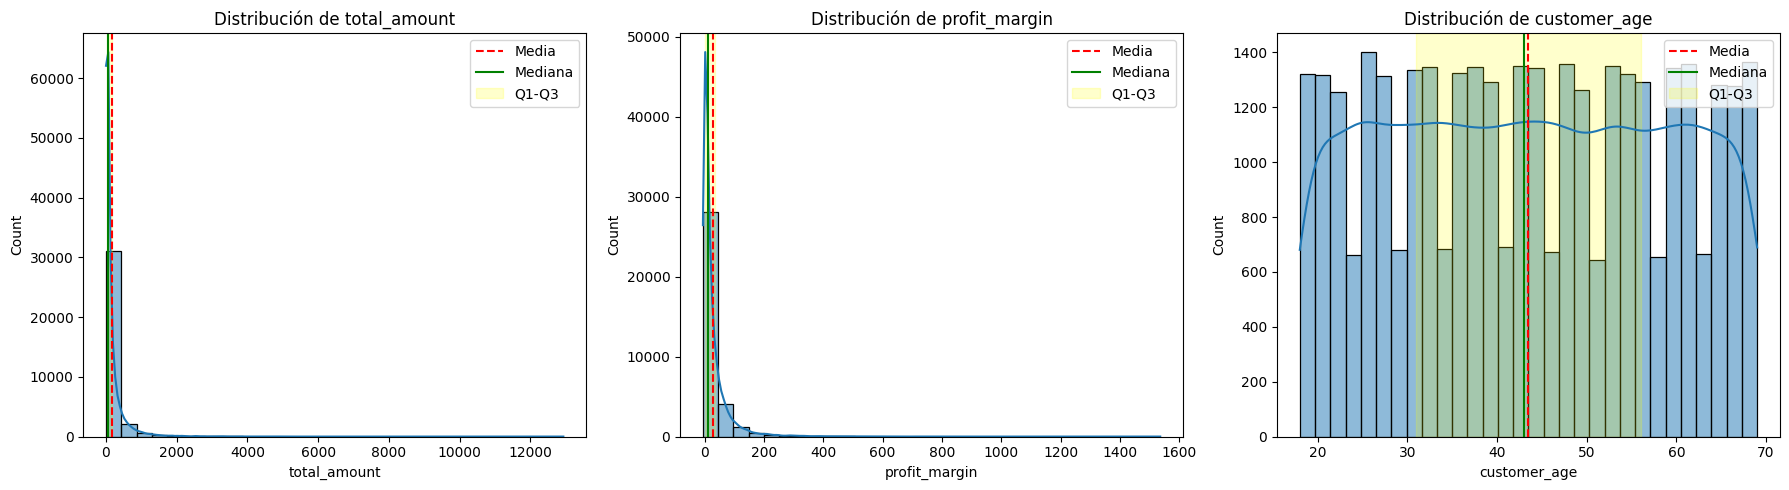

In [10]:
variables = ['total_amount', 'profit_margin', 'customer_age']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(variables):
    media = df[var].mean()
    mediana = df[var].median()
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)

    sns.histplot(df[var], kde=True, bins=30, ax=axes[i])
    axes[i].axvline(media, color='red', linestyle='--', label='Media')
    axes[i].axvline(mediana, color='green', linestyle='-', label='Mediana')
    axes[i].axvspan(q1, q3, alpha=0.2, color='yellow', label='Q1-Q3')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].legend()

plt.tight_layout()
plt.show()

### Cómo quitar outliers con IQR sin tocar el DF original

In [11]:
df_clean = df.copy()

for var in ['total_amount', 'profit_margin']:
    q1 = df_clean[var].quantile(0.25)
    q3 = df_clean[var].quantile(0.75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    df_clean = df_clean[(df_clean[var] >= lim_inf) & (df_clean[var] <= lim_sup)]

print("Filas originales:", len(df))
print("Filas limpias:", len(df_clean))
print("Filas eliminadas:", len(df) - len(df_clean))

Filas originales: 34500
Filas limpias: 28678
Filas eliminadas: 5822


### Idea para comentar en markdown
- Si hay cola larga a la derecha → **sesgo positivo**.
- Si media > mediana normalmente hay **sesgo a la derecha**.
- Tras quitar outliers, la distribución suele verse más simétrica.

## 3. Análisis univariante de variables categóricas

Variables típicas:
- `category`
- `payment_method`
- `region`
- `returned`

In [12]:
categoricas = ['category', 'payment_method', 'region', 'returned']

for var in categoricas:
    print(f"\nVariable: {var}")
    print("Moda:", df[var].mode()[0])
    print("Valores únicos:", df[var].unique())
    print("Número de categorías:", df[var].nunique())


Variable: category
Moda: Fashion
Valores únicos: ['Home' 'Grocery' 'Electronics' 'Beauty' 'Fashion' 'Toys' 'Sports']
Número de categorías: 7

Variable: payment_method
Moda: Credit Card
Valores únicos: ['Credit Card' 'UPI' 'COD' 'PayPal' 'Debit Card' 'Wallet']
Número de categorías: 6

Variable: region
Moda: South
Valores únicos: ['West' 'South' 'North' 'East' 'Central']
Número de categorías: 5

Variable: returned
Moda: No
Valores únicos: ['No' 'Yes']
Número de categorías: 2


### Frecuencia de `category`: barras y tarta en la misma figura

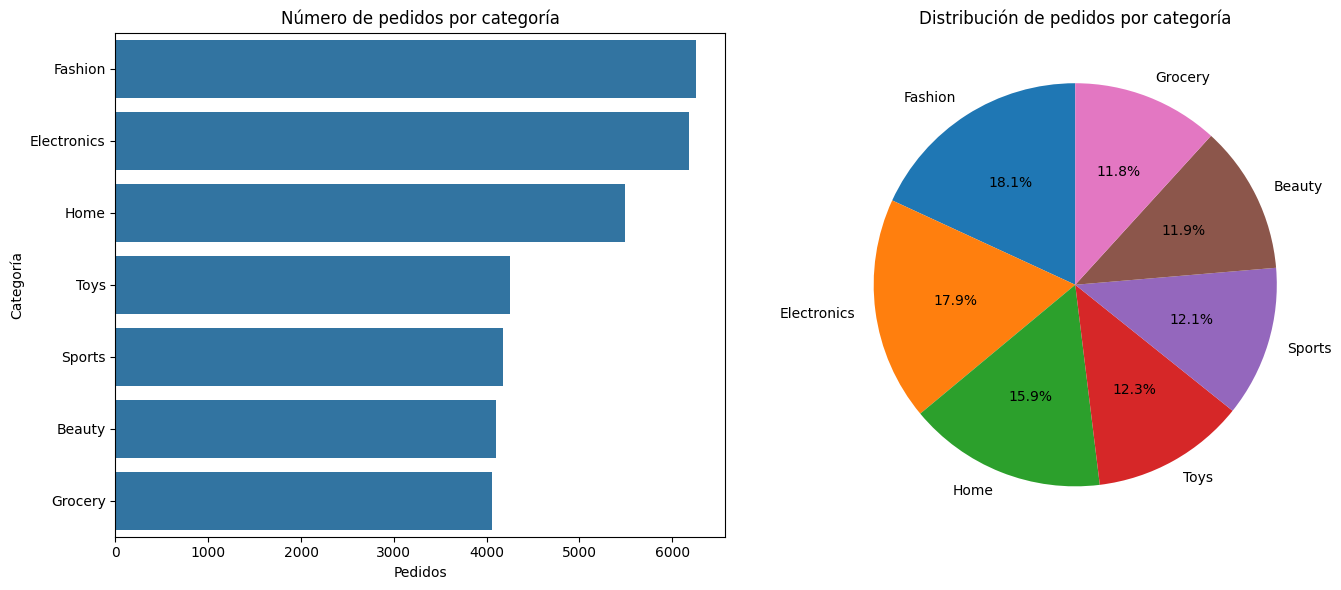

In [13]:
cat_counts = df['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[0])
axes[0].set_title("Número de pedidos por categoría")
axes[0].set_xlabel("Pedidos")
axes[0].set_ylabel("Categoría")

axes[1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title("Distribución de pedidos por categoría")

plt.tight_layout()
plt.show()

### Método de pago: gráfico de tarta

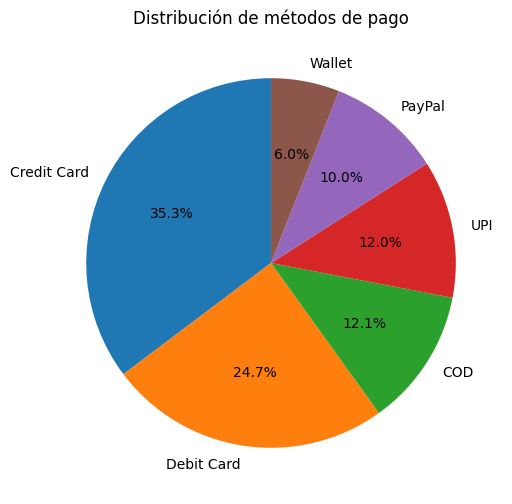

In [14]:
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribución de métodos de pago")
plt.show()

### Devoluciones por región: barras apiladas

returned,No,Yes
region,,
Central,5345,287
East,6496,408
North,7166,406
South,7153,431
West,6437,371


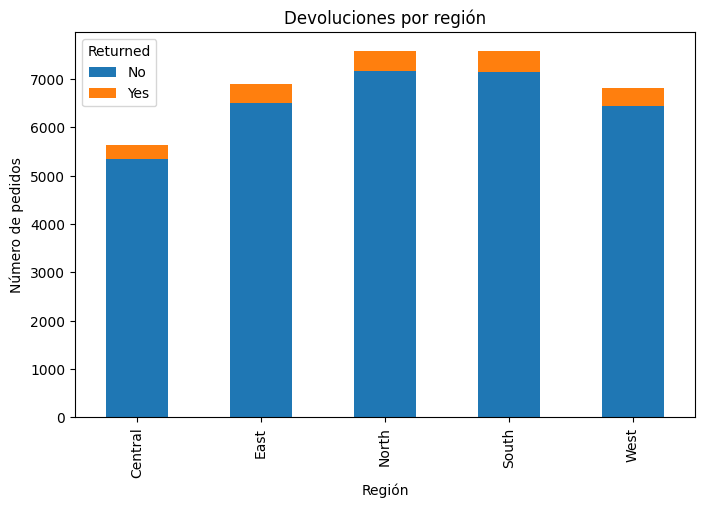

In [15]:
tabla_dev = pd.crosstab(df['region'], df['returned'])
display(tabla_dev)

tabla_dev.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title("Devoluciones por región")
plt.xlabel("Región")
plt.ylabel("Número de pedidos")
plt.legend(title="Returned")
plt.show()

### Porcentaje de devoluciones por región

In [16]:
porcentaje_dev = pd.crosstab(df['region'], df['returned'], normalize='index') * 100
display(porcentaje_dev)

returned,No,Yes
region,,
Central,94.904119,5.095881
East,94.090382,5.909618
North,94.638141,5.361859
South,94.316983,5.683017
West,94.550529,5.449471


## 4. ANOVA sobre `payment_method`

### Paso a paso
1. Boxplot.
2. Detectar outliers por grupo.
3. Limpiar outliers en una copia.
4. Hacer ANOVA.
5. Concluir con el p-valor.

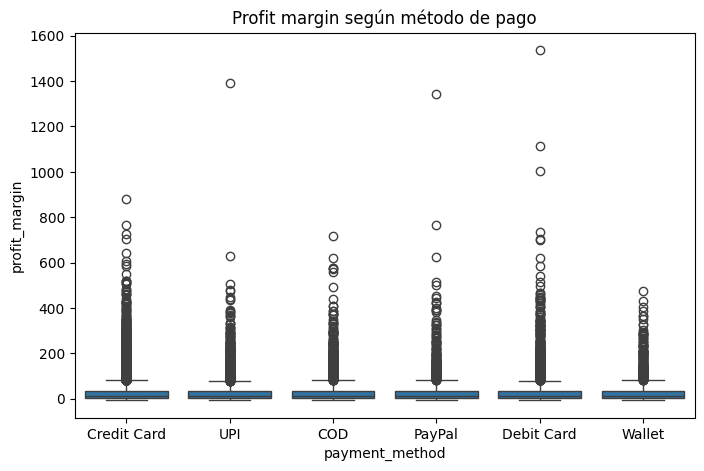

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='payment_method', y='profit_margin')
plt.title("Profit margin según método de pago")
plt.show()

In [18]:
outliers_info = []

for metodo, grupo in df.groupby('payment_method'):
    q1 = grupo['profit_margin'].quantile(0.25)
    q3 = grupo['profit_margin'].quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    n_outliers = ((grupo['profit_margin'] < limite_inf) | (grupo['profit_margin'] > limite_sup)).sum()

    outliers_info.append({
        'payment_method': metodo,
        'limite_inferior': limite_inf,
        'limite_superior': limite_sup,
        'num_outliers': n_outliers
    })

display(pd.DataFrame(outliers_info))

,payment_method,limite_inferior,limite_superior,num_outliers
0,COD,-46.73875,81.47125,340
1,Credit Card,-45.64250,80.33750,1079
2,Debit Card,-45.60500,80.11500,773
3,PayPal,-47.45500,82.82500,273
4,UPI,-45.26500,79.19500,383
5,Wallet,-47.12500,82.43500,175


In [19]:
df_clean_pay = df.copy()

for metodo, grupo in df_clean_pay.groupby('payment_method'):
    q1 = grupo['profit_margin'].quantile(0.25)
    q3 = grupo['profit_margin'].quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    df_clean_pay = df_clean_pay[
        ~(
            (df_clean_pay['payment_method'] == metodo) &
            (
                (df_clean_pay['profit_margin'] < limite_inf) |
                (df_clean_pay['profit_margin'] > limite_sup)
            )
        )
    ]

print("Filas originales:", len(df))
print("Filas limpias:", len(df_clean_pay))

Filas originales: 34500
Filas limpias: 31477


In [20]:
modelo = smf.ols('profit_margin ~ C(payment_method)', data=df_clean_pay).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
display(anova_table)

,sum_sq,df,F,PR(>F)
C(payment_method),2.867770e+03,5.0,1.492644,0.18844
Residual,1.209285e+07,31471.0,NaN,NaN


### Cómo interpretar
- Si **p-valor < 0.05** → sí hay diferencias significativas.
- Si **p-valor >= 0.05** → no puedes afirmar diferencias significativas.

## 5. ANOVA sobre `category` + Tukey

### Qué cambia respecto al bloque anterior
Igual que con `payment_method`, pero ahora agrupando por `category`.

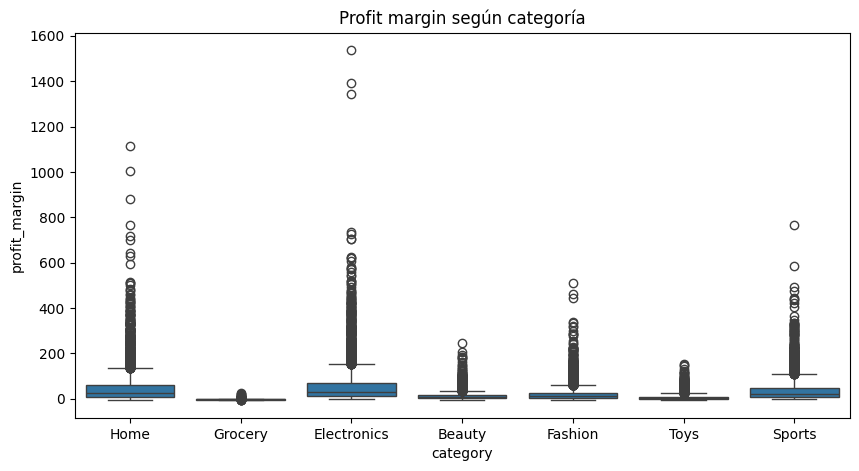

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='category', y='profit_margin')
plt.title("Profit margin según categoría")
plt.show()

In [22]:
outliers_info_cat = []

for categoria, grupo in df.groupby('category'):
    q1 = grupo['profit_margin'].quantile(0.25)
    q3 = grupo['profit_margin'].quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    n_outliers = ((grupo['profit_margin'] < limite_inf) | (grupo['profit_margin'] > limite_sup)).sum()

    outliers_info_cat.append({
        'category': categoria,
        'limite_inferior': limite_inf,
        'limite_superior': limite_sup,
        'num_outliers': n_outliers
    })

display(pd.DataFrame(outliers_info_cat))

,category,limite_inferior,limite_superior,num_outliers
0,Beauty,-18.4775,34.7425,330
1,Electronics,-70.9325,151.9475,455
2,Fashion,-30.7525,59.8275,439
3,Grocery,-5.7000,0.9400,90
4,Home,-66.5675,135.2125,399
5,Sports,-53.6325,110.1475,300
6,Toys,-14.5300,24.9900,326


In [23]:
df_clean_cat = df.copy()

for categoria, grupo in df_clean_cat.groupby('category'):
    q1 = grupo['profit_margin'].quantile(0.25)
    q3 = grupo['profit_margin'].quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    df_clean_cat = df_clean_cat[
        ~(
            (df_clean_cat['category'] == categoria) &
            (
                (df_clean_cat['profit_margin'] < limite_inf) |
                (df_clean_cat['profit_margin'] > limite_sup)
            )
        )
    ]

print("Filas originales:", len(df))
print("Filas limpias:", len(df_clean_cat))

Filas originales: 34500
Filas limpias: 32161


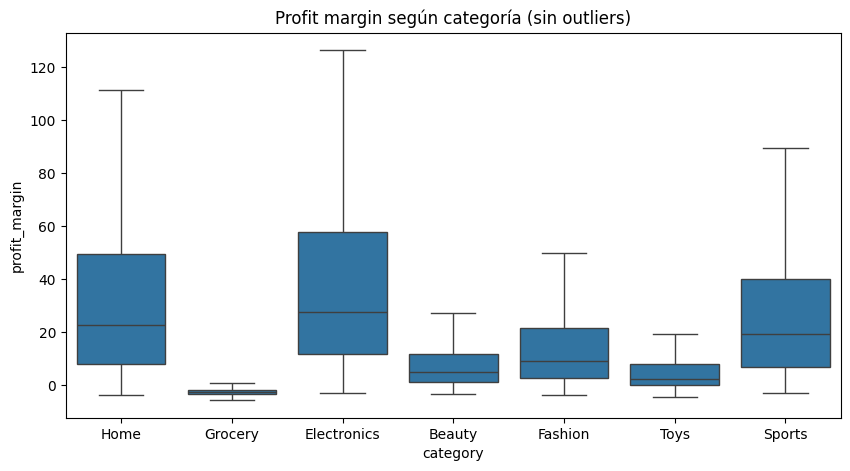

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean_cat, x='category', y='profit_margin', showfliers=False)
plt.title("Profit margin según categoría (sin outliers)")
plt.show()

In [25]:
modelo_cat = smf.ols('profit_margin ~ C(category)', data=df_clean_cat).fit()
anova_cat = sm.stats.anova_lm(modelo_cat, typ=2)
display(anova_cat)

,sum_sq,df,F,PR(>F)
C(category),6.800917e+06,6.0,2219.77731,0.0
Residual,1.641882e+07,32154.0,NaN,NaN


In [26]:
tukey = pairwise_tukeyhsd(
    endog=df_clean_cat['profit_margin'],
    groups=df_clean_cat['category'],
    alpha=0.05
)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj  lower    upper   reject
---------------------------------------------------------------
     Beauty Electronics  31.3905   0.0  29.9933  32.7876   True
     Beauty     Fashion   6.4842   0.0   5.0914    7.877   True
     Beauty     Grocery -10.0261   0.0 -11.5411   -8.511   True
     Beauty        Home  25.3989   0.0  23.9674  26.8304   True
     Beauty      Sports   19.811   0.0  18.2867  21.3353   True
     Beauty        Toys  -2.8013   0.0  -4.3208  -1.2818   True
Electronics     Fashion -24.9063   0.0 -26.1468 -23.6658   True
Electronics     Grocery -41.4165   0.0 -42.7928 -40.0402   True
Electronics        Home  -5.9916   0.0  -7.2753  -4.7078   True
Electronics      Sports -11.5795   0.0 -12.9659  -10.193   True
Electronics        Toys -34.1918   0.0 -35.5729 -32.8106   True
    Fashion     Grocery -16.5103   0.0 -17.8822 -15.1383   True
    Fashion        Home  18.9147   0.0  

### Cómo comentar Tukey
Tukey te dice **qué pares de categorías** son diferentes entre sí.

Fíjate sobre todo en:
- `reject = True` → diferencia significativa.
- `meandiff` → cuánto cambia la media entre categorías.

## 6. Correlación y relaciones entre variables

### 1. Matriz de correlación

In [27]:
numericas_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numericas_df.corr()
display(corr_matrix)

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
price,1.000000,0.008736,0.005324,0.007612,0.801426,0.654110,0.679105,-0.010550
discount,0.008736,1.000000,-0.008431,0.002490,-0.031202,-0.046383,-0.047470,0.000181
quantity,0.005324,-0.008431,1.000000,0.005120,0.304134,0.278292,0.388398,0.000352
delivery_time_days,0.007612,0.002490,0.005120,1.000000,0.005495,0.007651,0.005832,0.003624
total_amount,0.801426,-0.031202,0.304134,0.005495,1.000000,0.599079,0.893327,-0.009870
shipping_cost,0.654110,-0.046383,0.278292,0.007651,0.599079,1.000000,0.616730,-0.008951
profit_margin,0.679105,-0.047470,0.388398,0.005832,0.893327,0.616730,1.000000,-0.007712
customer_age,-0.010550,0.000181,0.000352,0.003624,-0.009870,-0.008951,-0.007712,1.000000


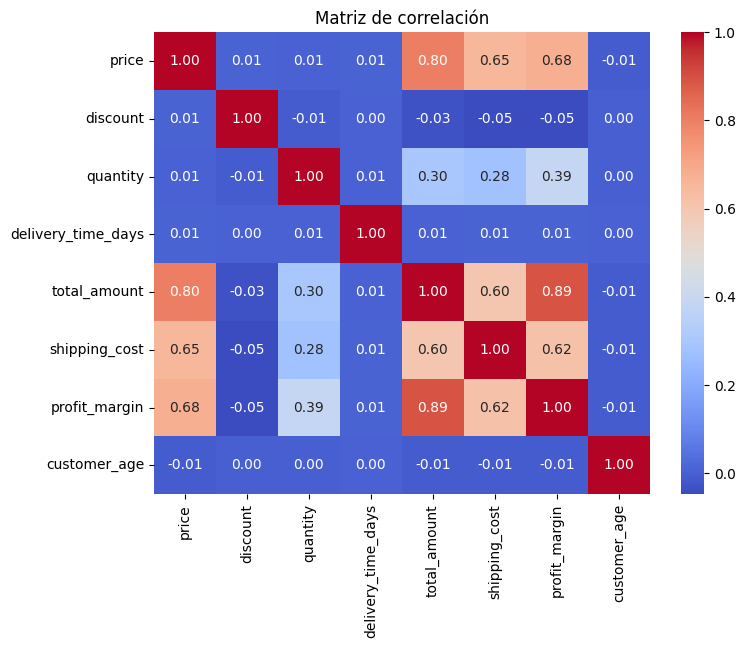

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de correlación")
plt.show()

### 2. Scatter plots con recta de regresión

Puedes poner los 3 pares que más te interesen.

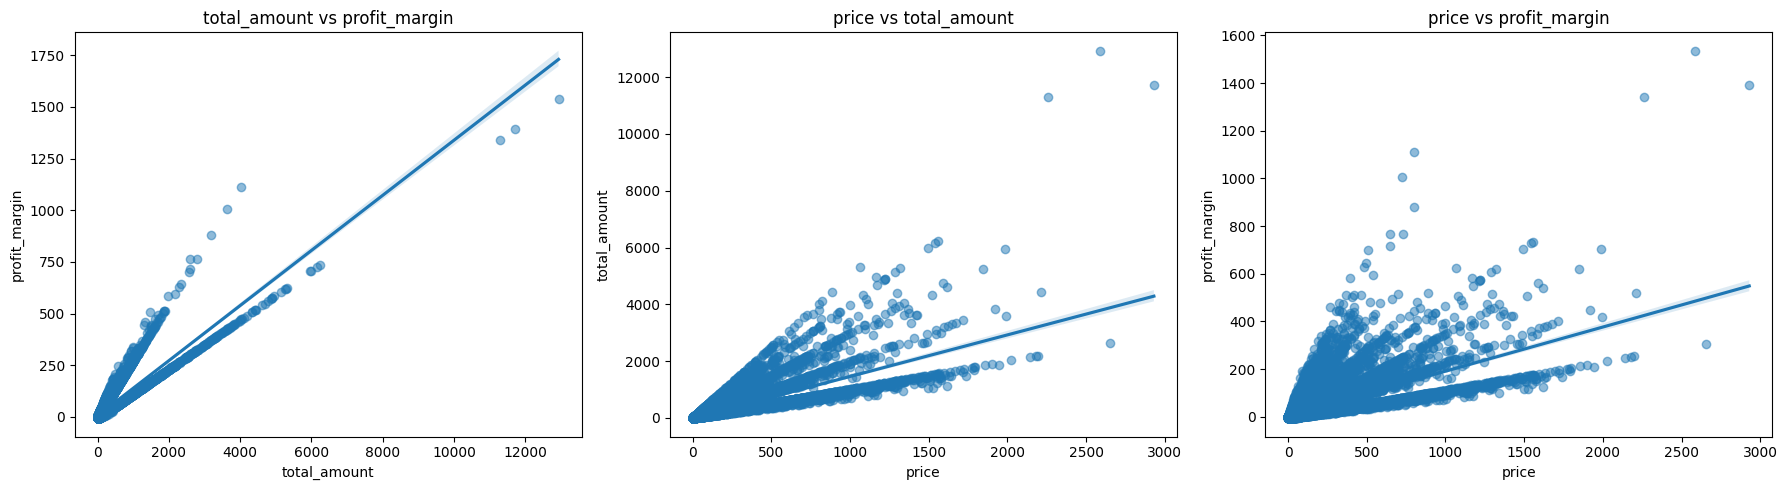

In [29]:
pares = [
    ('total_amount', 'profit_margin'),
    ('price', 'total_amount'),
    ('price', 'profit_margin')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (x, y) in enumerate(pares):
    sns.regplot(data=df, x=x, y=y, ax=axes[i], scatter_kws={'alpha': 0.5})
    axes[i].set_title(f'{x} vs {y}')

plt.tight_layout()
plt.show()

### Idea clave
- correlación cercana a **1** → positiva fuerte,
- cercana a **-1** → negativa fuerte,
- cercana a **0** → relación lineal débil.

## 7. Series temporales

Aquí hubo una corrección importante:

- en tu caso la fecha era `order_date`, no `date`,
- y la columna de ventas en unidades puede no llamarse `items`.

### Antes de agrupar, comprueba los nombres

In [30]:
print(df.columns.tolist())

['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender']


### Conversión de fecha

In [31]:
df['order_date'] = pd.to_datetime(df['order_date'])

### Agrupación diaria

Si tu columna de unidades vendidas no se llama `items`, cambia ese nombre por el real.
Ejemplos típicos: `quantity`, `units_sold`, `order_quantity`.

In [33]:
# CAMBIA 'items' si en tu CSV esa columna tiene otro nombre real
ventas_dia = df.groupby('order_date').agg({
    'quantity': 'sum',
    'total_amount': 'sum',
    'profit_margin': 'sum'
}).reset_index()

display(ventas_dia.head())

,order_date,quantity,total_amount,profit_margin
0,2023-09-12,55,6727.75,1148.55
1,2023-09-13,58,9678.11,1507.96
2,2023-09-14,47,5622.59,721.55
3,2023-09-15,56,5531.77,934.28
4,2023-09-16,52,10853.21,1524.93


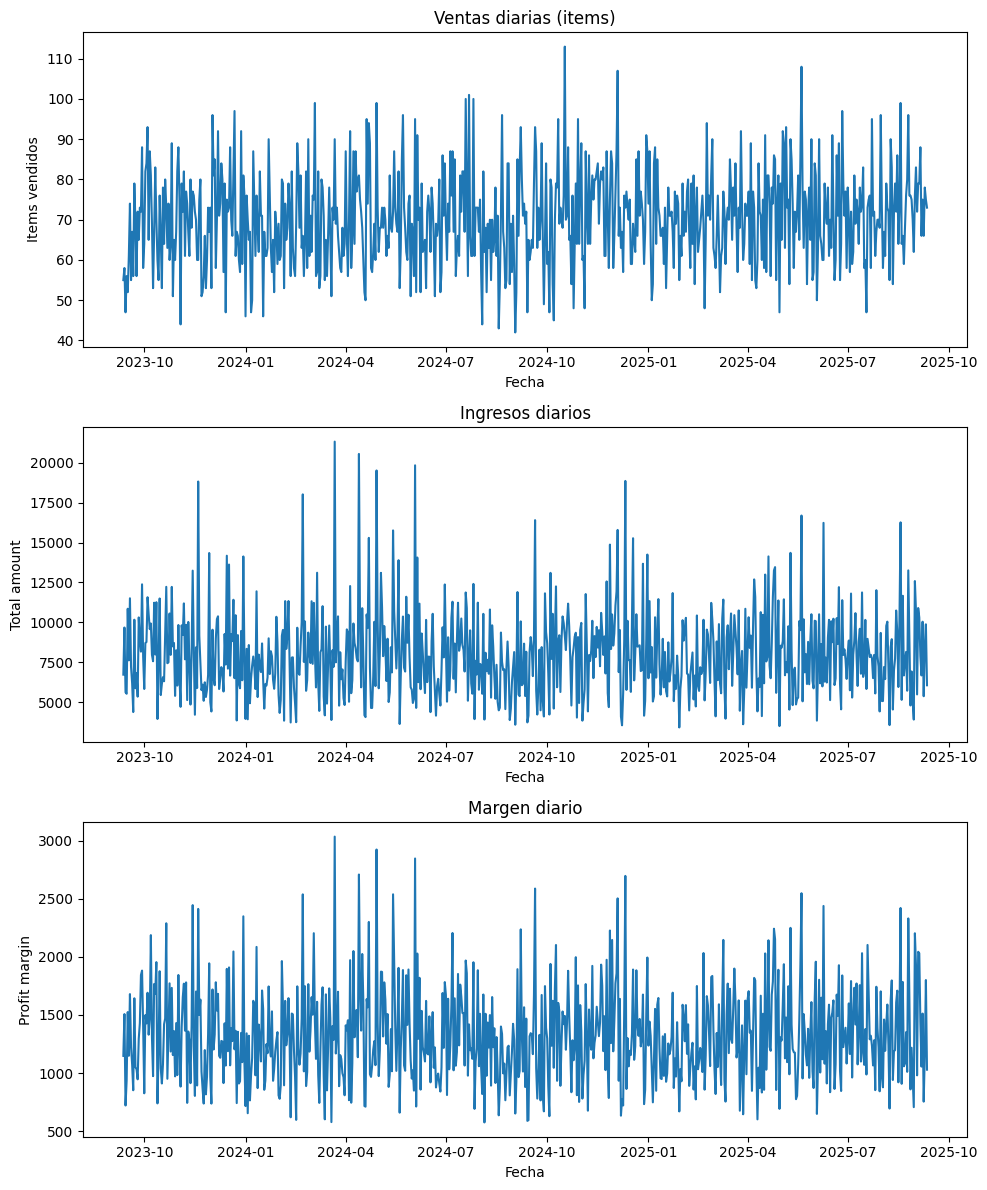

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(ventas_dia['order_date'], ventas_dia['quantity'])
axes[0].set_title("Ventas diarias (items)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Items vendidos")

axes[1].plot(ventas_dia['order_date'], ventas_dia['total_amount'])
axes[1].set_title("Ingresos diarios")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Total amount")

axes[2].plot(ventas_dia['order_date'], ventas_dia['profit_margin'])
axes[2].set_title("Margen diario")
axes[2].set_xlabel("Fecha")
axes[2].set_ylabel("Profit margin")

plt.tight_layout()
plt.show()

### Media móvil de 30 días

In [35]:
ventas_dia['quantity_ma30'] = ventas_dia['quantity'].rolling(window=30).mean()
ventas_dia['total_amount_ma30'] = ventas_dia['total_amount'].rolling(window=30).mean()
ventas_dia['profit_margin_ma30'] = ventas_dia['profit_margin'].rolling(window=30).mean()

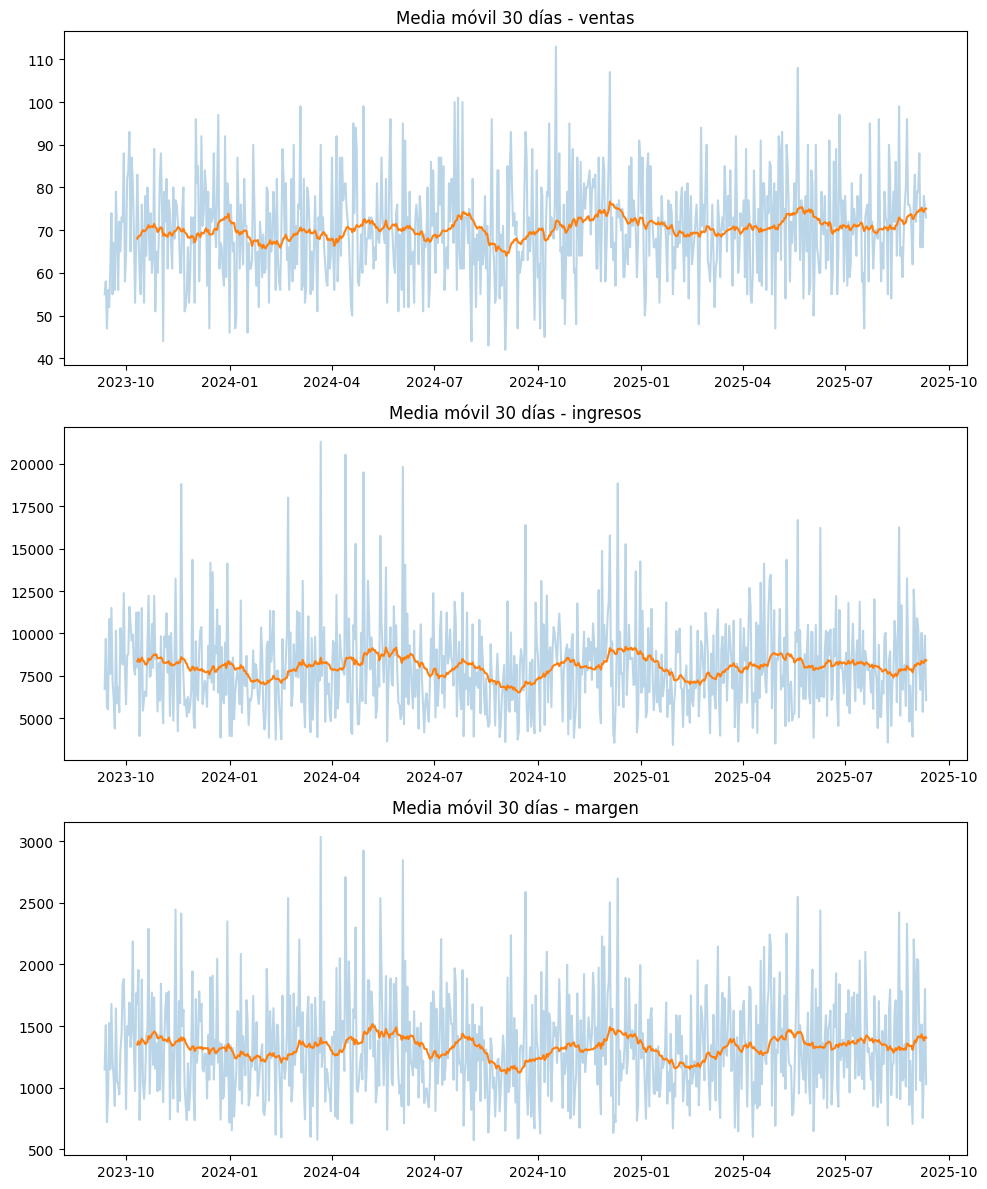

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(ventas_dia['order_date'], ventas_dia['quantity'], alpha=0.3)
axes[0].plot(ventas_dia['order_date'], ventas_dia['quantity_ma30'])
axes[0].set_title("Media móvil 30 días - ventas")

axes[1].plot(ventas_dia['order_date'], ventas_dia['total_amount'], alpha=0.3)
axes[1].plot(ventas_dia['order_date'], ventas_dia['total_amount_ma30'])
axes[1].set_title("Media móvil 30 días - ingresos")

axes[2].plot(ventas_dia['order_date'], ventas_dia['profit_margin'], alpha=0.3)
axes[2].plot(ventas_dia['order_date'], ventas_dia['profit_margin_ma30'])
axes[2].set_title("Media móvil 30 días - margen")

plt.tight_layout()
plt.show()

### Agrupación mensual

In [37]:
ventas_mes = df.groupby(df['order_date'].dt.to_period('M')).agg({
    'quantity': 'sum',
    'total_amount': 'sum',
    'profit_margin': 'sum'
}).reset_index()

ventas_mes['order_date'] = ventas_mes['order_date'].astype(str)
display(ventas_mes.head())

,order_date,quantity,total_amount,profit_margin
0,2023-09,1213,151135.60,24346.72
1,2023-10,2178,262502.74,43048.19
2,2023-11,2049,240286.91,40044.23
3,2023-12,2269,255617.03,41385.45
4,2024-01,2043,217766.09,37604.38


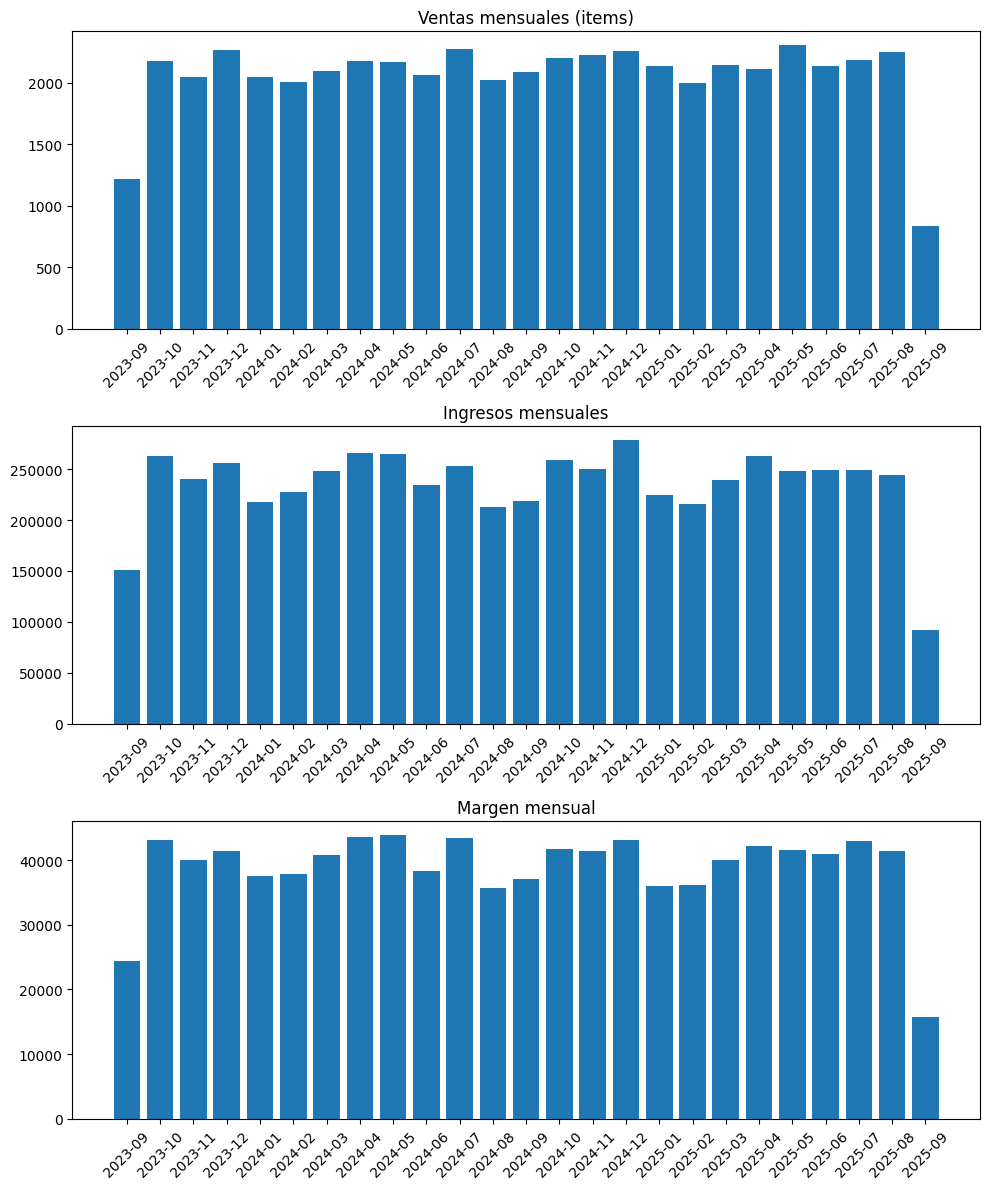

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].bar(ventas_mes['order_date'], ventas_mes['quantity'])
axes[0].set_title("Ventas mensuales (items)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(ventas_mes['order_date'], ventas_mes['total_amount'])
axes[1].set_title("Ingresos mensuales")
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(ventas_mes['order_date'], ventas_mes['profit_margin'])
axes[2].set_title("Margen mensual")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Errores típicos que te pueden salir

### Error 1
```python
KeyError: 'date'
```
**Motivo:** la columna no se llama `date`, sino por ejemplo `order_date`.

### Error 2
```python
KeyError: "Column(s) ['items'] do not exist"
```
**Motivo:** la columna de unidades vendidas tiene otro nombre.

### Error 3
`statsmodels` no instalado.

Solución:
```python
!pip install statsmodels
```

## 9. Mini checklist para el examen

### Si te piden EDA:
- `info()`
- `describe()`
- `isnull().sum()`
- `head()`

### Si te piden numéricas:
- media, mediana, cuartiles, IQR
- histograma + KDE
- outliers con IQR

### Si te piden categóricas:
- `mode()`
- `unique()`
- `value_counts()`
- `crosstab()`

### Si te piden segmentación:
- `boxplot`
- limpiar outliers por grupo
- ANOVA

### Si te piden comparaciones entre grupos:
- Tukey

### Si te piden relaciones:
- `corr()`
- `heatmap`
- `regplot`

### Si te piden temporal:
- convertir fecha con `pd.to_datetime`
- agrupar por día o mes
- media móvil

## 10. Último consejo

En examen, mejor:
1. hacerlo claro,
2. usar nombres de variables limpios,
3. no tocar el DF original si vas a limpiar,
4. comentar en markdown con frases cortas y directas.

Lo más importante no es escribir muchísimo, sino que:
- el código funcione,
- el análisis tenga sentido,
- la conclusión coincida con el resultado.